<a href="https://colab.research.google.com/github/ruksana-ux/ML-models/blob/main/Assignments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ASSIGNMENT ON MACHINE LEARNING ON 24/9/2026**

# **Importing libraries**

**Why we import these libraries:**

1. **numpy as np:** library for numerical operations.

2. **pandas as pd:** this is used for data manipulation, data cleaning and structured data analysis. * used for saving Dataframe from csv files

3. **matplotlib.pyplot as plt:** library for plotting graph.

4. **seaborn as sns:** library for statistical data visualization.

5. **sklearn:** scikit learn is a open source in python library used specifically for ML predictive data analysis ans statistical modelling.

* we import scikit-learn into python because  it provides in-built highly optimized tools so that we dont have to code complex machine learning algorithm from scratch

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Machine Learning related imports
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Other utilities
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

**Loading dataset**

In [ ]:
df = pd.read_csv("HR_Employee_Attrition-1.csv")

# **Data overview**


**To check first five rows of the dataset**

In [ ]:
df.head()

,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,Yes,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,2,No,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,3,Yes,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,4,No,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0
4,5,No,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2


**To check the shape od the dataset**

In [ ]:
df.shape

(2940, 35)

**Obsevations:**

* There are 2940 rows 35 columns.

**To check last 5 rows of the dataset**

In [ ]:
df.tail()

,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2935,2936,No,36,Travel_Frequently,884,Research & Development,23,2,Medical,1,...,3,80,1,17,3,3,5,2,0,3
2936,2937,No,39,Travel_Rarely,613,Research & Development,6,1,Medical,1,...,1,80,1,9,5,3,7,7,1,7
2937,2938,No,27,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,...,2,80,1,6,0,3,6,2,0,3
2938,2939,No,49,Travel_Frequently,1023,Sales,2,3,Medical,1,...,4,80,0,17,3,2,9,6,0,8
2939,2940,No,34,Travel_Rarely,628,Research & Development,8,3,Medical,1,...,1,80,0,6,3,4,4,3,1,2


**To check missing values**

In [ ]:
df.isnull().sum()

,0
EmployeeNumber,0
Attrition,0
Age,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


**To Check the data types of the columns for the dataset.**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            2940 non-null   int64 
 1   Attrition                 2940 non-null   object
 2   Age                       2940 non-null   int64 
 3   BusinessTravel            2940 non-null   object
 4   DailyRate                 2940 non-null   int64 
 5   Department                2940 non-null   object
 6   DistanceFromHome          2940 non-null   int64 
 7   Education                 2940 non-null   int64 
 8   EducationField            2940 non-null   object
 9   EmployeeCount             2940 non-null   int64 
 10  EnvironmentSatisfaction   2940 non-null   int64 
 11  Gender                    2940 non-null   object
 12  HourlyRate                2940 non-null   int64 
 13  JobInvolvement            2940 non-null   int64 
 14  JobLevel                

**Observations:**

* There are no null values.
* Attrition, BusinessTravel, Department,EducationField, Gender, JobRole, MaritalStatus, Over18, Overtime are in object type and converting them to categorical data type.

* **converting "objects" to "category" reduces the data space required to store the dataframe.**

**Fixing the data types**

In [ ]:
cols = df.select_dtypes(["object"])
cols.columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [ ]:
for i in cols.columns:
  df[i] = df[i].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   EmployeeNumber            2940 non-null   int64   
 1   Attrition                 2940 non-null   category
 2   Age                       2940 non-null   int64   
 3   BusinessTravel            2940 non-null   category
 4   DailyRate                 2940 non-null   int64   
 5   Department                2940 non-null   category
 6   DistanceFromHome          2940 non-null   int64   
 7   Education                 2940 non-null   int64   
 8   EducationField            2940 non-null   category
 9   EmployeeCount             2940 non-null   int64   
 10  EnvironmentSatisfaction   2940 non-null   int64   
 11  Gender                    2940 non-null   category
 12  HourlyRate                2940 non-null   int64   
 13  JobInvolvement            2940 non-null   int64 

**Observations:**

* Object is converted to categorical values.

**To check duplicate values**

In [ ]:
duplicate_count = df.duplicated().sum()
print(duplicate_count)

0


**Observations:**

* there are no or zero duplicate values.

**To check statistical summary of the dataset**

**df.describe().T:**

* This funtion Transposes the output tabele.
* The columns of original datafreame become the rows and statistical measures become the columns.


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EmployeeNumber,2940.0,1470.500000,848.849221,1.0,735.75,1470.5,2205.25,2940.0
Age,2940.0,36.923810,9.133819,18.0,30.00,36.0,43.00,60.0
DailyRate,2940.0,802.485714,403.440447,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,2940.0,9.192517,8.105485,1.0,2.00,7.0,14.00,29.0
Education,2940.0,2.912925,1.023991,1.0,2.00,3.0,4.00,5.0
EmployeeCount,2940.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EnvironmentSatisfaction,2940.0,2.721769,1.092896,1.0,2.00,3.0,4.00,4.0
HourlyRate,2940.0,65.891156,20.325969,30.0,48.00,66.0,84.00,100.0
JobInvolvement,2940.0,2.729932,0.711440,1.0,2.00,3.0,3.00,4.0
JobLevel,2940.0,2.063946,1.106752,1.0,1.00,2.0,3.00,5.0


**Observations:**

* The average age of employees is approximately 36.9 years, ranging from 18 to 60. therefore mean and median are almost close.

*  The mean being higher than the median suggests a right-skewed distribution, meaning there are some employees with significantly higher monthly incomes.

*  The average distance from home is about 9.2 units, with a range from 1 to 29. The mean is close to the median (7), suggesting a fairly even distribution.

In [ ]:
df.describe(include=['category']).T

,count,unique,top,freq
Attrition,2940,2,No,2466
BusinessTravel,2940,3,Travel_Rarely,2086
Department,2940,3,Research & Development,1922
EducationField,2940,6,Life Sciences,1212
Gender,2940,2,Male,1764
JobRole,2940,9,Sales Executive,652
MaritalStatus,2940,3,Married,1346
Over18,2940,1,Y,2940
OverTime,2940,2,No,2108


**Dropping columns which are not required**

* EmploymentNumber, EmploymentCount, StandardHours, Over18 are columns not required.

In [ ]:
df.drop(['EmployeeNumber','EmployeeCount','StandardHours','Over18'],axis = 1, inplace = True)

**To check Unique Values**

In [ ]:
cols_cat = df.select_dtypes('category')

* **print(cols_cat[i].value_counts()):** This is the core of the snippet. For each column i:

* **cols_cat[i]** selects that specific column (which is a pandas Series).

* **.value_counts()** is then called on this Series. This method returns a Series containing counts of unique values in that column in descending order.

In [ ]:
for i in cols_cat.columns: # this initiates a loop that iterates through everycolumn name present in cols_cat.
    print('Unique values in',i, 'are :') # this prints which column's unique value is displayed.
    print(cols_cat[i].value_counts())
    print('*'*50)

Unique values in Attrition are :
Attrition
No     2466
Yes     474
Name: count, dtype: int64
**************************************************
Unique values in BusinessTravel are :
BusinessTravel
Travel_Rarely        2086
Travel_Frequently     554
Non-Travel            300
Name: count, dtype: int64
**************************************************
Unique values in Department are :
Department
Research & Development    1922
Sales                      892
Human Resources            126
Name: count, dtype: int64
**************************************************
Unique values in EducationField are :
EducationField
Life Sciences       1212
Medical              928
Marketing            318
Technical Degree     264
Other                164
Human Resources       54
Name: count, dtype: int64
**************************************************
Unique values in Gender are :
Gender
Male      1764
Female    1176
Name: count, dtype: int64
**************************************************
Unique va

In [ ]:
df = df.copy()

# **Data Analysis**

**Exploratory Data Analysis**

* It is first step in data analysis.
* It involves statistical summaries and graphical represntations  to understand the characteristics od the dataset.
* Its purpse of this is to discover patterns

* there are different types of EDA:
   1. Univariate Analysis
   2. Bivariate Anlysis
   3. Multivariate Analysis

**Univariate Analysis**

* It is a type EDA which involves in analysing single variable.

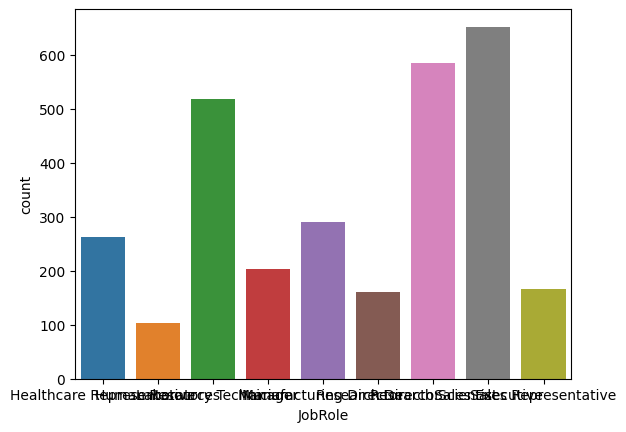

In [ ]:
sns.countplot(x='JobRole',data=df, hue = 'JobRole');

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
def labeled_barplot(data, feature, perc=False, n=None):


    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()

**Observations on NumCompaniesWorked**

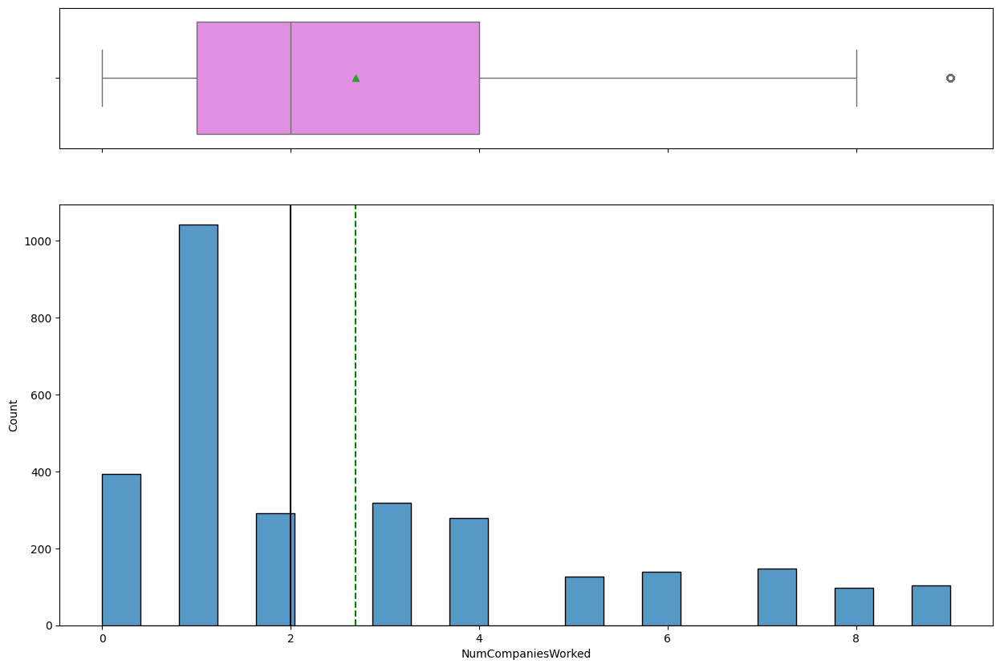

In [ ]:
histogram_boxplot(df,'NumCompaniesWorked')

**Observations:**

* The majority of employees have worked for a relatively small number of companies.

*  the mean is greater than the median indicates a right-skewed distribution.

* The median number of companies worked for is around 2, with the mean being slightly higher at approximately 2.69.

* The number of employees worked between 1 to 4 companies.

* There are outliers representing employees who have worked for large number of companies.


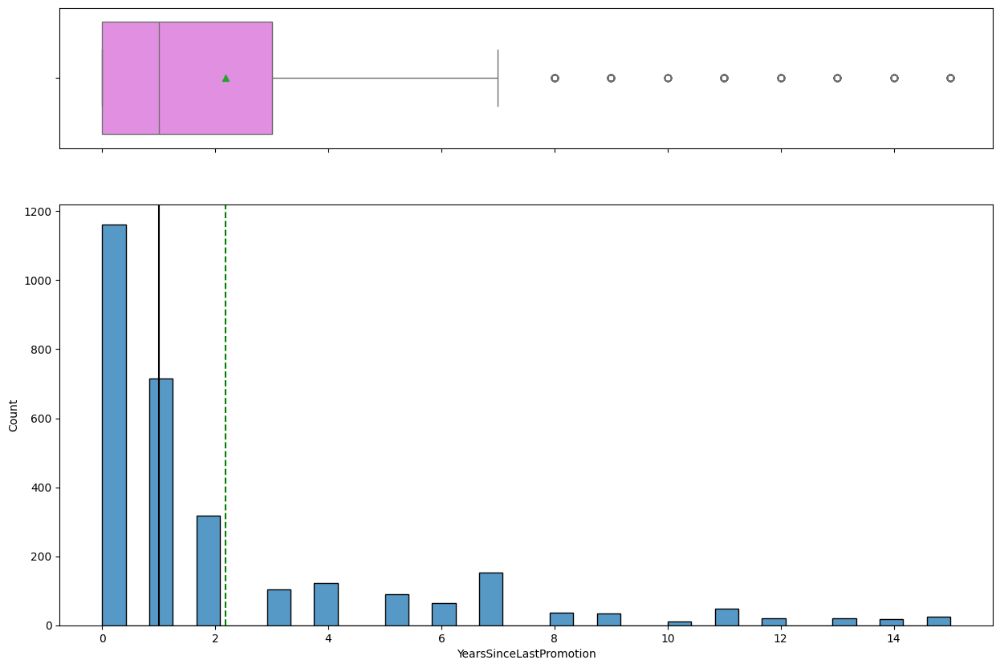

In [ ]:
histogram_boxplot(df,'YearsSinceLastPromotion')

**Observations:**

* There are a few outliers in this right-skewed distribution, these are probably the people at the highest positions.

**Observations on JobRole by using Labeled bar plot**

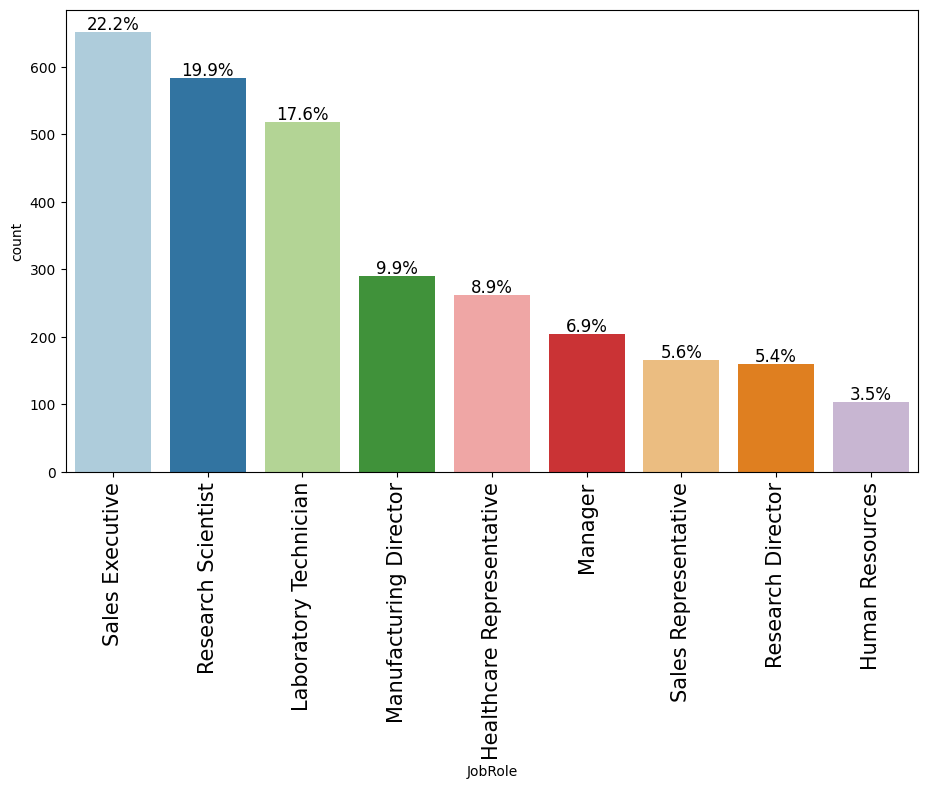

In [ ]:
labeled_barplot(df, "JobRole", perc = True)

Observations:

* Most number of employees are sales executives ie; 22.2%.
* least number of employees are in the Human resource ie; 3.5%

**Observations on Attrition by using labelled barplot**

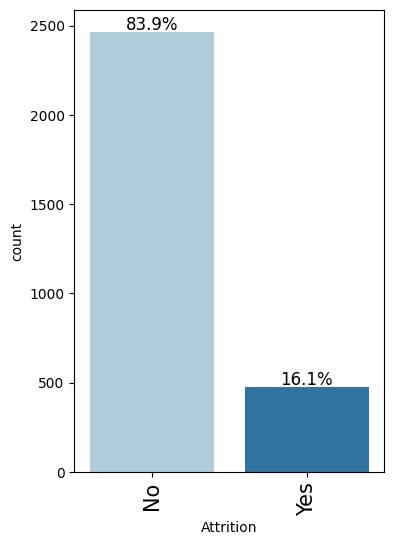

In [ ]:
labeled_barplot(df, "Attrition", perc = True) # perc is boolean parameter it can be true or false.

**Observations:**

* the employees who are going to attrite is 16%

**Bivariate Analysis**

* Bivariate analysis is a type of statistical analysis that explores the relationship between two variables.

**corelation check:**

* A correlation check (or correlation analysis) is a statistical method used to evaluate the strength and direction of a linear relationship between two or more quantitative variables.

* **Positive Correlation:** As one variable increases, the other tends to increase (e.g., more study time might correlate with higher grades).

* **Negative Correlation:** As one variable increases, the other tends to decrease (e.g., more hours of exercise might correlate with lower body fat).

* **No Correlation:** There's no consistent linear relationship between the variables.

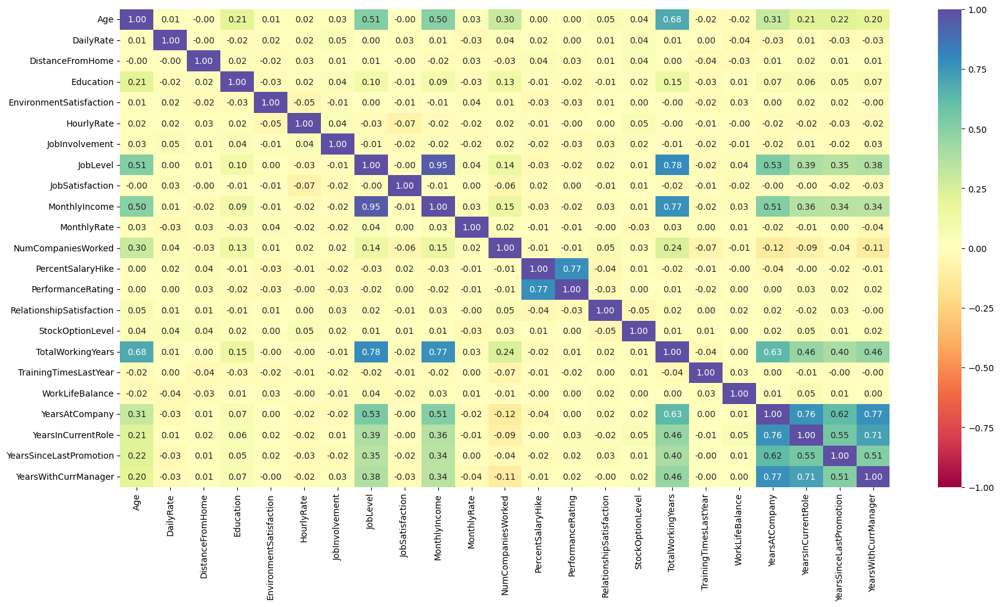

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,vmin=-1,vmax=1,fmt='.2f',cmap="Spectral")
plt.show()

**Observations:**

* There are a few variables that are correlated with each other.

* TotalWorkingYears is highly correlated to Job Level.

* HourlyRate, DailyRate, and MonthlyRate are completely uncorrelated with each other.

* MonthlyIncome is highly correlated to Job Level.

* Age is positively correlated JobLevel and Education.

**Observation between NumCompaniesWorked and TotalWorkingYears**

<Axes: xlabel='NumCompaniesWorked', ylabel='TotalWorkingYears'>

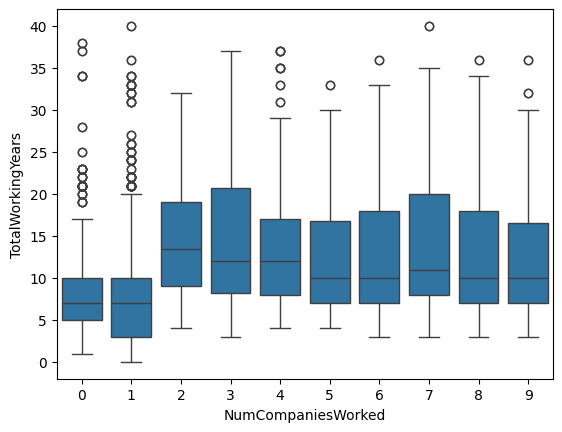

In [ ]:
sns.boxplot(x = "NumCompaniesWorked", y = "TotalWorkingYears", data = df)

**Observations between BusinessTravel and Attrition**

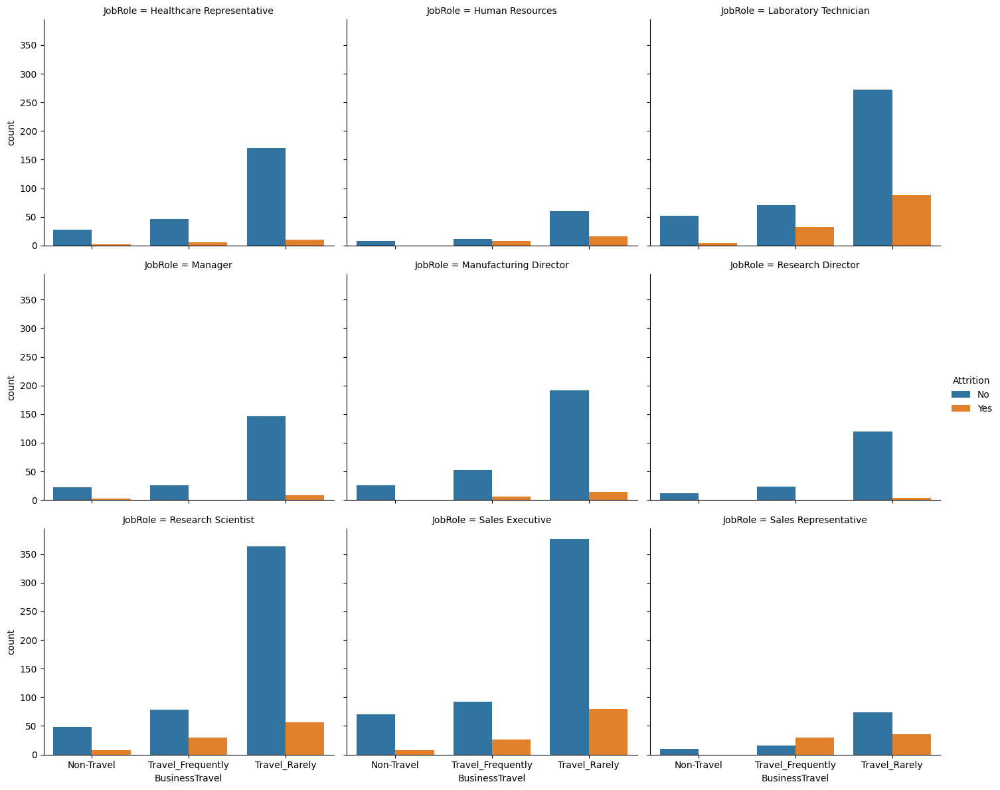

In [ ]:
sns.catplot(data=df, x='BusinessTravel', hue='Attrition', col='JobRole', kind='count', col_wrap=3, height=4, aspect=1.2);

**Observation on Monthly Income and MonthlyRate**

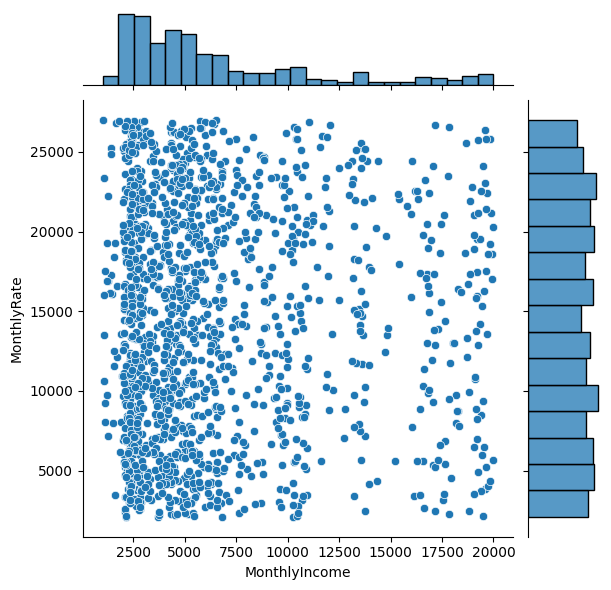

In [ ]:
sns.jointplot(data = df, x = 'MonthlyIncome', y = 'MonthlyRate');

**Observation on Monthly Income and MonthlyRate**

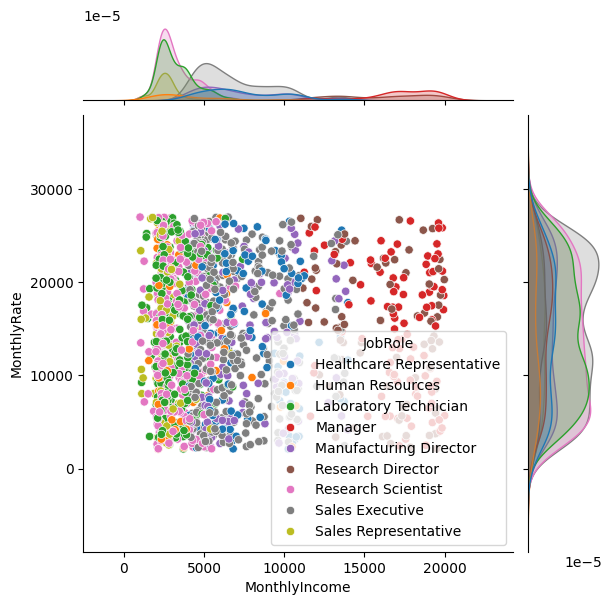

In [ ]:
sns.jointplot(data = df, x = 'MonthlyIncome', y = 'MonthlyRate', hue = 'JobRole');

**Observation on total working years and years at company**

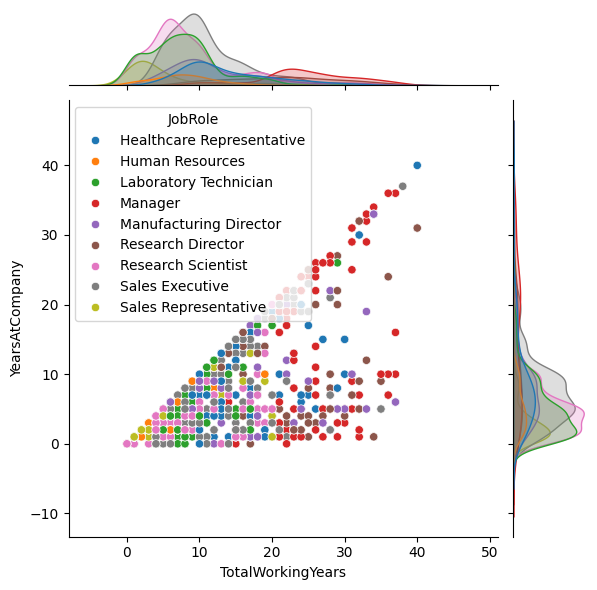

In [ ]:
sns.jointplot(data = df, x = 'TotalWorkingYears', y = 'YearsAtCompany', hue = 'JobRole');

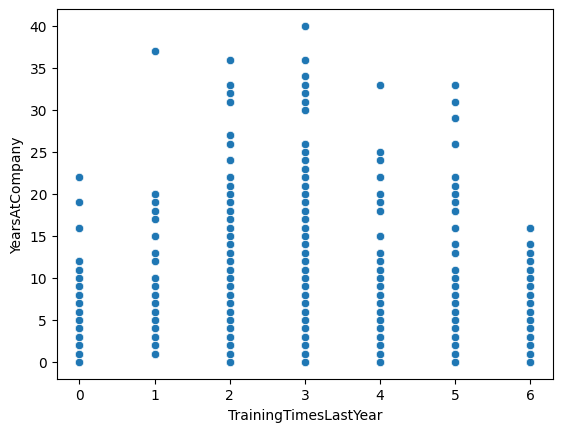

In [ ]:
sns.scatterplot(x = 'TrainingTimesLastYear',y = 'YearsAtCompany', data = df);

**obervations ons= years since last promotion vs years with current manager**

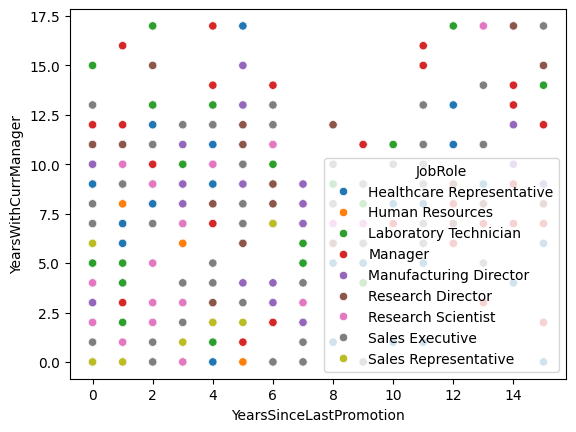

In [ ]:
sns.scatterplot(x = 'YearsSinceLastPromotion',y = 'YearsWithCurrManager', data = df, hue = 'JobRole');

**Checking if performace rating and salary hike are related-**

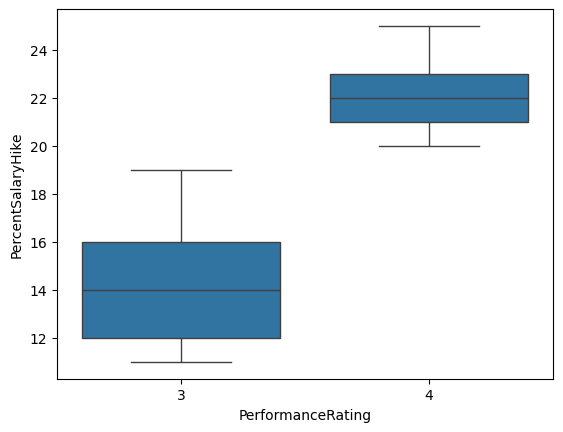

In [ ]:
sns.boxplot(x=df['PerformanceRating'],y=df['PercentSalaryHike'])
plt.show()

**Observations on Attrition vs Department**

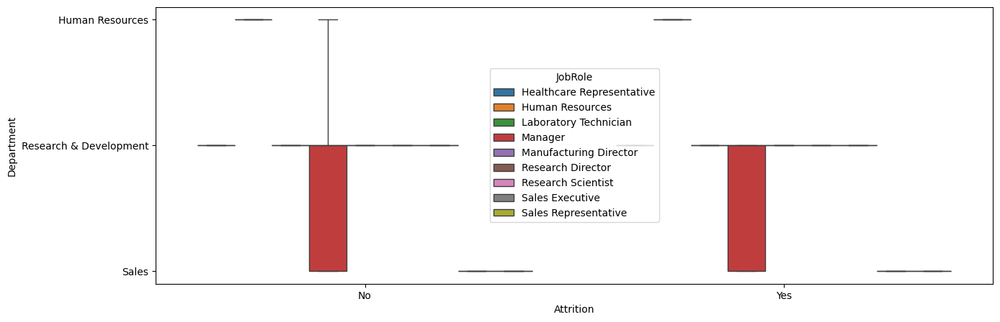

In [ ]:
plt.figure(figsize=(15,5))
sns.boxplot(x=df['Attrition'],y=df['Department'],hue=df['JobRole'])
plt.show()

**Observations**

* Some departments might exhibit generally higher or lower overall attrition rates compared to others.

* certain departments, specific job roles could show significantly higher (or lower) attrition tendencies.

* The plot might highlight any individual job roles within a department that are outliers in terms of attrition behavior compared to their departmental peers.

### Mathematical Steps to Calculate Attrition Rates

In [ ]:
# 1. Overall Attrition Rate
overall_attrition_rate = df['Attrition'].value_counts(normalize=True).loc[1]
print(f"Overall Attrition Rate: {overall_attrition_rate:.2%}\n")

# 2. Attrition Rate per Department
attrition_by_department = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()
attrition_by_department['Attrition_Rate'] = attrition_by_department[1]
print("Attrition Rate by Department:")
display(attrition_by_department[['Attrition_Rate']].sort_values(by='Attrition_Rate', ascending=False))

# 3. Attrition Rate per Job Role
attrition_by_jobrole = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack()
attrition_by_jobrole['Attrition_Rate'] = attrition_by_jobrole[1]
print("\nAttrition Rate by Job Role:")
display(attrition_by_jobrole[['Attrition_Rate']].sort_values(by='Attrition_Rate', ascending=False))

**Obseravtions on Performance rate vs Percentsalary hike**

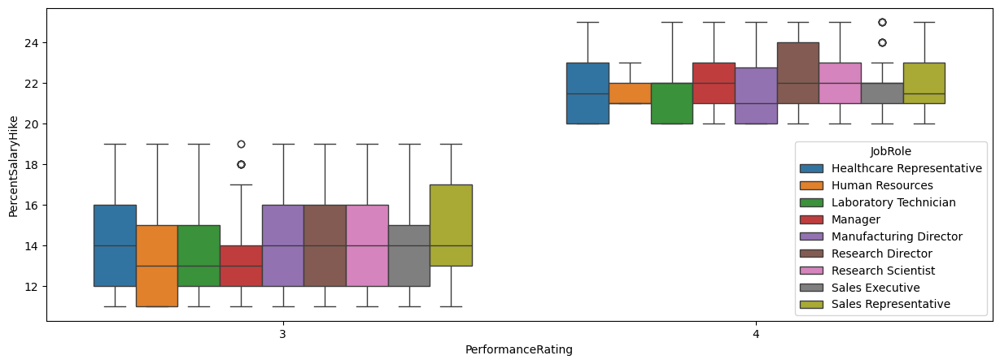

In [ ]:
plt.figure(figsize=(15,5))
sns.boxplot(x=df['PerformanceRating'],y=df['PercentSalaryHike'],hue=df['JobRole'])
plt.show()

**Observations**

* Salary hikes are a function of Performance ratings.

* We have to investigate why the employees who get Excellent(3) and Outstanding(4) Performance rating attrite and how then can they be retained.

**Observation on Attrition vs jobrole**

<Axes: xlabel='JobRole', ylabel='Attrition'>

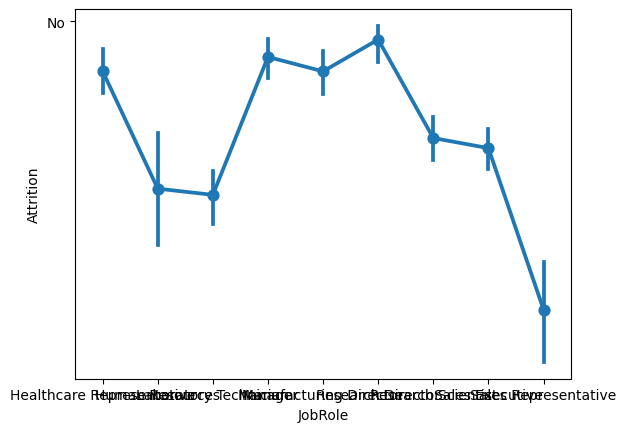

In [ ]:
sns.pointplot(x=df['JobRole'], y = df['Attrition'], data = df)

**Observations**

* Different job roles exhibit different average attrition rates.

* Some job roles might have a noticeably higher mean attrition rate(points higher on the y-axis).

* the vertical bars (confidence intervals) around each point indicate the precision of the estimated mean attrition rate for that job role.

* Overlapping bars suggest no significant difference between the attrition rates of those job roles.

**Observation on overtime and attrition**

<Axes: xlabel='OverTime', ylabel='Attrition'>

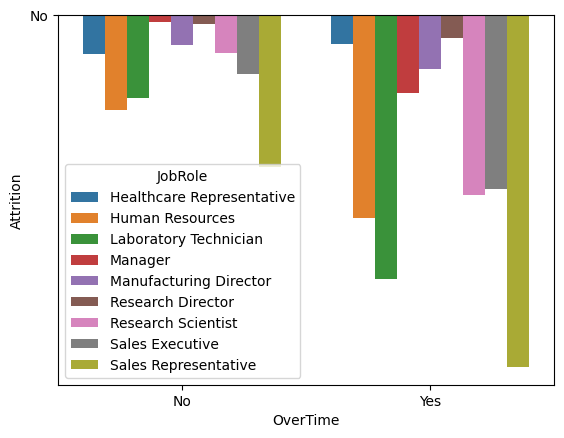

In [ ]:
sns.barplot(x = df['OverTime'], y = df['Attrition'], data = df, errorbar = None, hue = 'JobRole')

---

**Observations:**

*   **Impact of OverTime**: Employees who work OverTime generally exhibit a higher attrition rate compared to those who do not, across most job roles. This suggests that working overtime is a significant factor contributing to attrition.

*  The attrition rates vary significantly across different JobRoles for both OverTime categories.

*  Certain JobRoles show a particularly high attrition rate when employees work OverTime. For example, 'Sales Representative' and 'Laboratory Technician' might stand out as having very high attrition when working overtime.



**Observation on Attrition vs Earnings of employee**

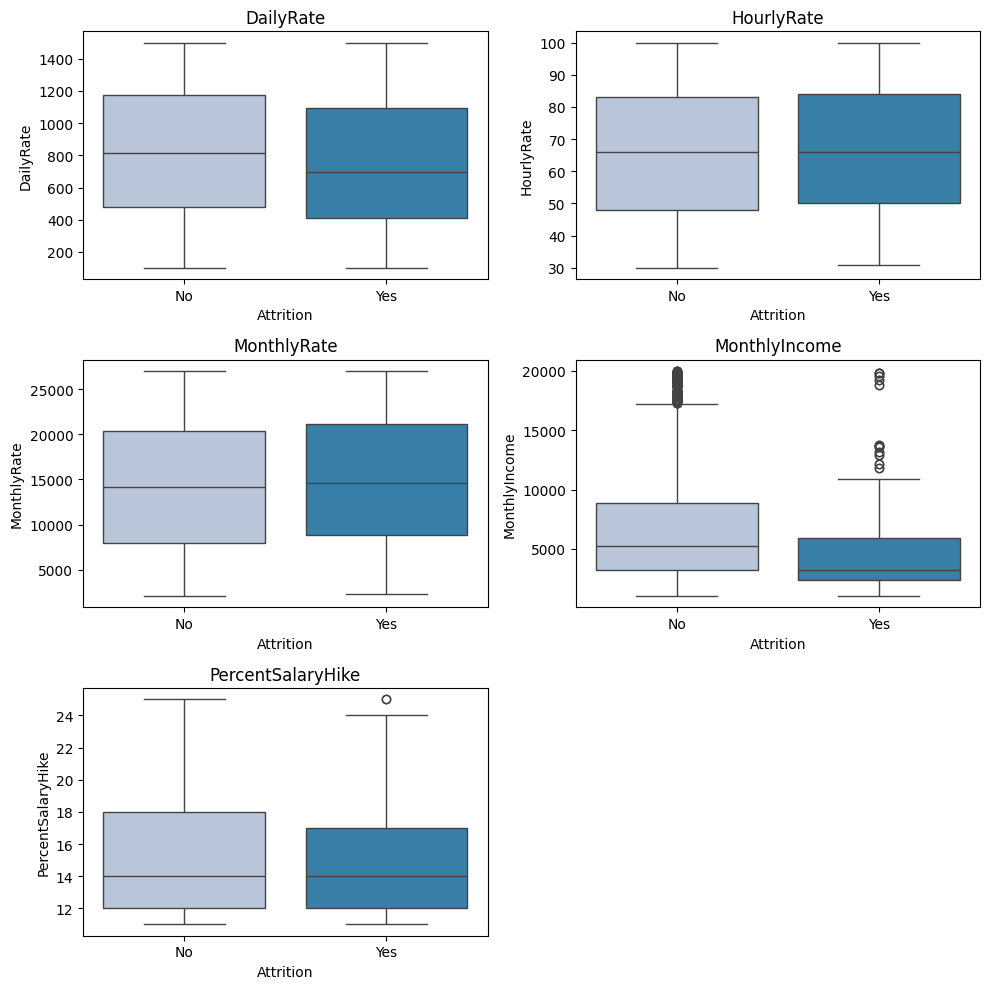

In [ ]:
cols = df[['DailyRate','HourlyRate','MonthlyRate','MonthlyIncome','PercentSalaryHike']].columns.tolist()
plt.figure(figsize=(10,10))

for i, variable in enumerate(cols):
                     plt.subplot(3,2,i+1)
                     sns.boxplot(x=df["Attrition"],y=df[variable],palette="PuBu")
                     plt.tight_layout()
                     plt.title(variable)
plt.show()

**Observations:**

* Employees having lower Daily rate and less monthly wage are more likely to attrite.

* Monthly rate and the hourly rate doesn't seem to have any effect on attrition.

* Lesser salary hike also contributes to attrition.

**Observations on Job involvement vs Joblevel**

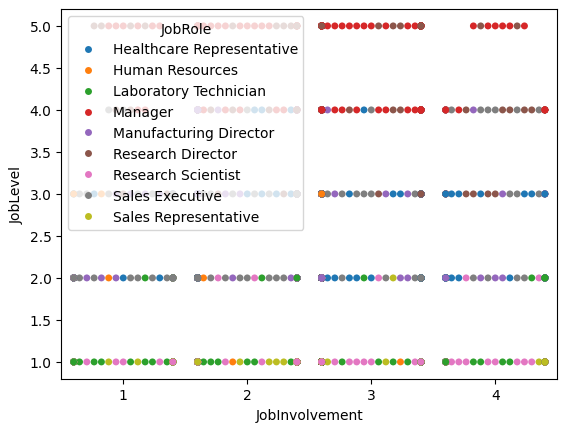

In [ ]:
sns.swarmplot(x='JobInvolvement',data=df,y ='JobLevel', hue = 'JobRole');

**Multivariate analysis**

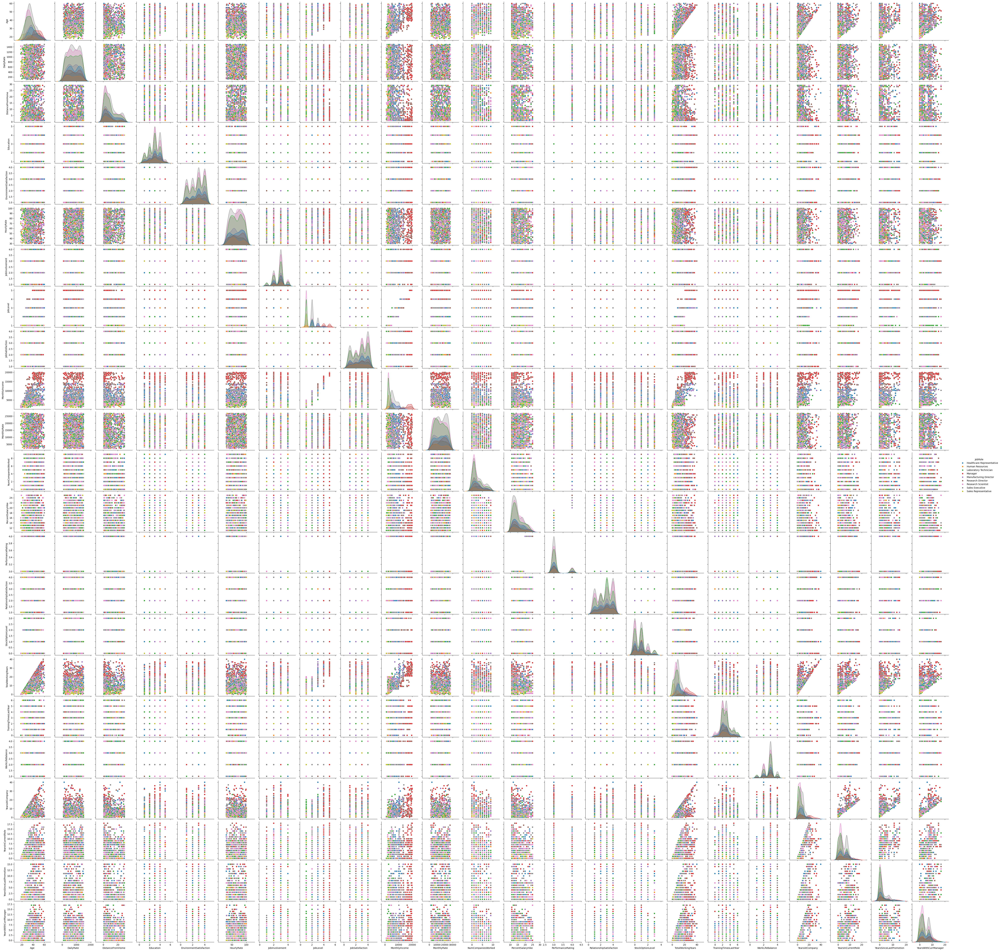

In [ ]:
sns.pairplot(df,hue="JobRole")

# **Data Preprocessing**

**Outlier Detection and Treatment**

* Outliers are data points that significantly differ from other observations.

* They can be due to variability in the measurement or errors. T

* hey can skew statistical analyses and model training if not handled appropriately.

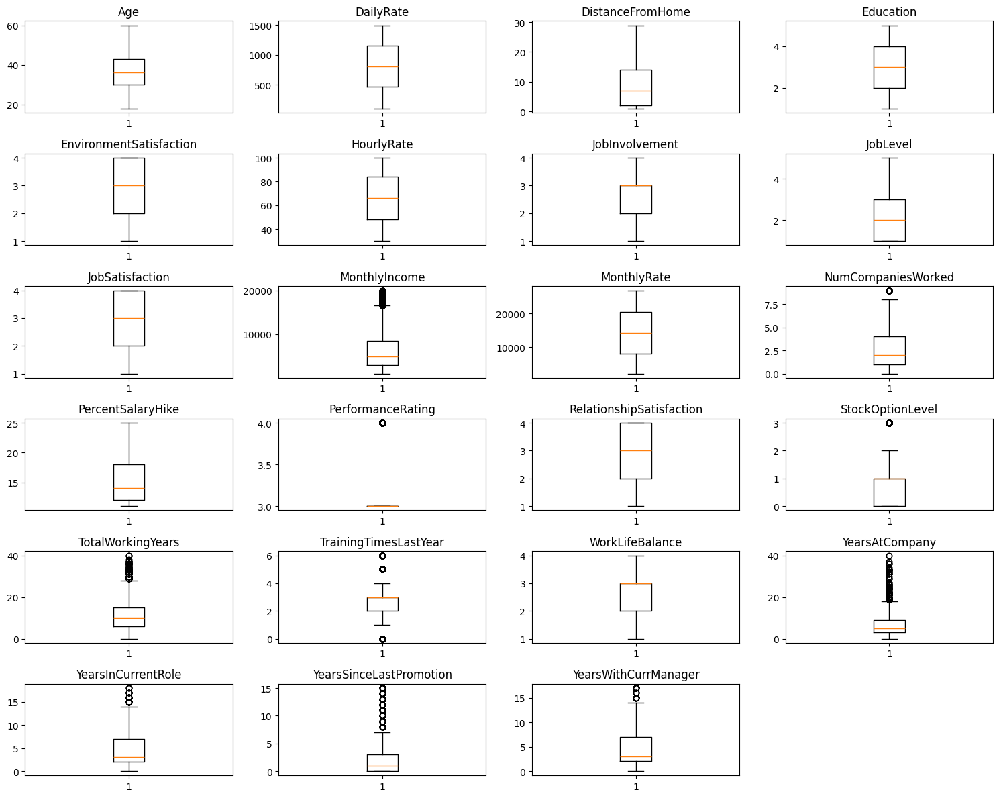

In [ ]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(6, 4, i + 1)
    #the whis parameter used here which controls the length of the whiskers.
    plt.boxplot(df[variable], whis=1.5)  # whis is set to 1.5, it means the whiskers extend to 1.5 times the Interquartile Range (IQR) beyond the upper and lower quartiles.
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Observations:**

* There are few outliers in the dataset.

# **Data Preparataion and model building**

In [ ]:
df['Attrition'] = df['Attrition'].apply(lambda x : 1 if x=='Yes' else 0)

X = df.drop(['Attrition'],axis = 1)
y = df['Attrition']

X = pd.get_dummies(X, drop_first = True)

**Splitting the dataset into Training and Testing**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1,stratify=y)


**To check shape of X_train, X_test**

In [ ]:
print(X_train.shape, X_test.shape)

(2058, 44) (882, 44)


* **This shows the counts of each unique value in the y series.**

**Observations**

* The ouput indicate there are 1470 instances where the Attrition value is 0, and no other values are present.

In [ ]:
print(y.value_counts(normalize = True))

Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64


In [ ]:
print(y_test.value_counts(1))

Attrition
0    0.839002
1    0.160998
Name: proportion, dtype: float64


**Observations:**

* The output Attrition 0 1.0 means that the value 0 constitutes 100% of the values in the y series.

# **Feature Scaling**

Feature scaling is crucial for many machine learning algorithms, especially those that calculate distances between data points (like KNN) or use gradient descent (like Logistic Regression). It helps to normalize the range of independent variables or features of the data. In this step, we will use `StandardScaler` to transform the numerical features so they have a mean of 0 and a standard deviation of 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature scaling complete for X_train and X_test.")

Feature scaling complete for X_train and X_test.


# **Plotting using confusion matrix**

*  **Confusion Matrix** is a performance measurement for machine learning classification problems where the output can be two or more classes.

* It's a table with four different combinations of predicted and actual values.

* It helps you visualize and understand the performance of a classification model.

4 key components:
   1. **True Positive (TP):** The model correctly predicted the positive class
    (e.g., predicted 'Yes' and the actual was 'Yes').

   2. **True Negative (TN):** The model correctly predicted the negative class
   (e.g., predicted 'No' and the actual was 'No').

   3. **False Positive (FP):** The model incorrectly predicted the positive class.
     * This is also known as a Type I error. (e.g., predicted 'Yes' but the actual was 'No').

  4. **False Negative (FN):** The model incorrectly predicted the negative class.
    * This is also known as a Type II error. (e.g., predicted 'No' but the actual was 'Yes').


In [ ]:
def model_performance_classification_sklearn(model, predictors, target):

   # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):

    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

# **Model Building**

# **Logistic Regression Model**

Logistic Regression is a linear model for classification. Despite its name, it's a classification algorithm used to estimate the probability of a binary outcome. It's often a good baseline model.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Using class_weight to handle imbalance, similar to your previous models
log_reg = LogisticRegression(class_weight={0:0.17, 1:0.83}, random_state=1, solver='liblinear')

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight={0: 0.17, 1: 0.83}, random_state=1,
                   solver='liblinear')

**Plotting confusion matrix for Training Data (Logistic Regression)**

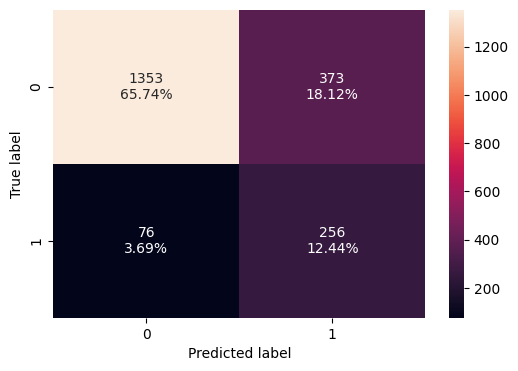

In [ ]:
confusion_matrix_sklearn(log_reg, X_train_scaled, y_train)

**To check the accuracy of the Training Data (Logistic Regression)**

In [ ]:
log_reg_train_perf = model_performance_classification_sklearn(log_reg, X_train_scaled, y_train)
print("Training performance (Logistic Regression):\n", log_reg_train_perf)

Training performance (Logistic Regression):
    Accuracy    Recall  Precision        F1
0  0.781827  0.771084   0.406995  0.532778


**Plotting confusion matrix for Test Data (Logistic Regression)**

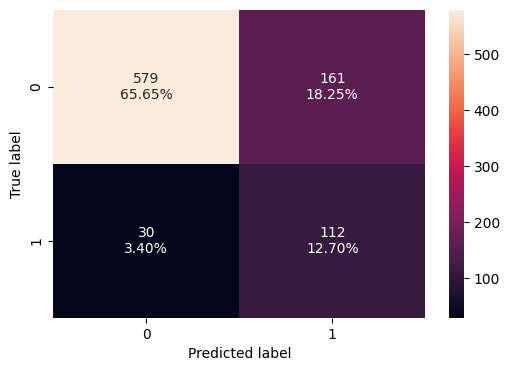

In [ ]:
confusion_matrix_sklearn(log_reg, X_test_scaled, y_test)

**To check the accuracy of the Test Data (Logistic Regression)**

In [ ]:
log_reg_test_perf = model_performance_classification_sklearn(log_reg, X_test_scaled, y_test)
print("Testing performance (Logistic Regression):\n", log_reg_test_perf)

Testing performance (Logistic Regression):
    Accuracy    Recall  Precision        F1
0  0.783447  0.788732   0.410256  0.539759


**Observations:**

* The model shows very similar performance metrics across both the training and testing sets.
   * This indicates that the model is not overfitting to the training data, which is a positive sign for its generalization ability.

*  Both the training (77.11%) and testing (78.87%) recall scores are relatively high.
   * This means the model is quite good at identifying employees who actually will attrite.

* the precision scores are quite low, both for training (40.70%) and testing (41.03%).
   * This suggests that when the model predicts an employee will attrite, it is only correct about 41% of the time.

* The F1-scores (53.28% training, 53.98% testing) are moderate. The F1-score is the harmonic mean of precision and recall.

# **K-Nearest Neighbors (KNN) Model**

KNN is a non-parametric, lazy learning algorithm used for both classification and regression. It classifies a data point based on how its neighbors are classified. Feature scaling is essential for KNN as it relies on distance metrics.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# to tune `n_neighbors` later
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model on scaled training data
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

**Plotting confusion matrix for Training Data (KNN)**

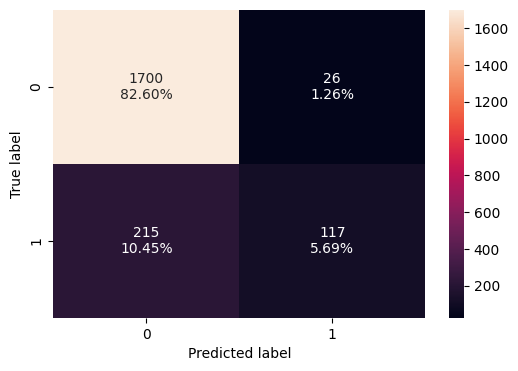

In [ ]:
confusion_matrix_sklearn(knn, X_train_scaled, y_train)

**To check the accuracy of the Training Data (KNN)**

In [ ]:
knn_train_perf = model_performance_classification_sklearn(knn, X_train_scaled, y_train)
print("Training performance (KNN):\n", knn_train_perf)

Training performance (KNN):
    Accuracy   Recall  Precision        F1
0  0.882896  0.35241   0.818182  0.492632


**Plotting confusion matrix for Test Data (KNN)**

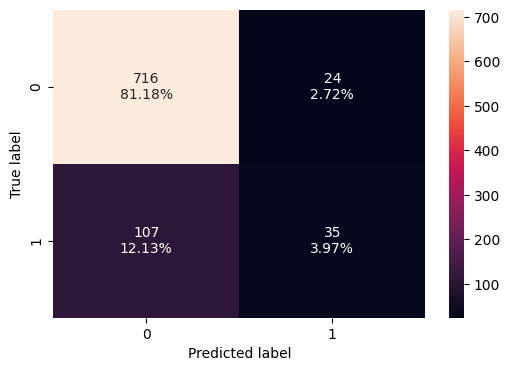

In [ ]:
confusion_matrix_sklearn(knn, X_test_scaled, y_test)

**To check the accuracy of the Test Data (KNN)**

In [ ]:
knn_test_perf = model_performance_classification_sklearn(knn, X_test_scaled, y_test)
print("Testing performance (KNN):\n", knn_test_perf)

Testing performance (KNN):
    Accuracy    Recall  Precision        F1
0  0.851474  0.246479    0.59322  0.348259


**Observations:**

* Overfitting Tendency: While the accuracy drop from training (88.3%) to testing (85.1%) is not extremely severe.

* significant drops in Recall (from 35.2% to 24.6%).

* Precision (from 81.8% to 59.3%),

* F1-Score (from 49.3% to 34.8%)

*  the model is overfitting to the training data. It performs noticeably worse on unseen test data.

* the most critical issue is the low recall, especially on the test set (24.6%). This means that the model is only able to correctly identify about a quarter of the employees who actually attrite.

* The precision on the test set (59.3%) indicates that when the model predicts an employee will attrite, it's correct about 59% of the time. This means roughly 40% of its positive predictions are false alarms.

* the low F1-scores for both training and testing (especially testing at 34.8%) confirm that the model struggles to achieve a good balance between precision and recall.

  * therefore, It's not effectively identifying positive cases without generating too many false positives or missing too many actual positives.

# **Decision tree classifier**

In [ ]:
dtree =  DecisionTreeClassifier(criterion = 'gini' , class_weight = {0:0.17,1:0.83}, random_state = 1)

In [ ]:
dtree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.17, 1: 0.83}, random_state=1)

**Plotting confusion matrix for Training**

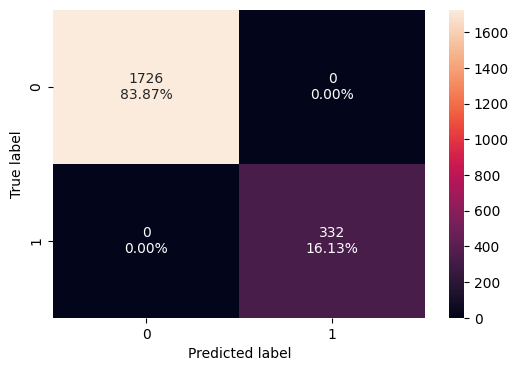

In [ ]:
confusion_matrix_sklearn(dtree, X_train, y_train)

**To check the accuracy of the training performance**

In [ ]:
dtree_model_train_perf = model_performance_classification_sklearn(dtree, X_train, y_train)
print("Training performance \n",dtree_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


**Plotting confusion matrix for test data**

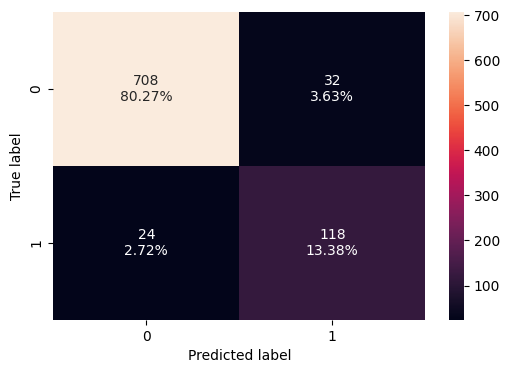

In [ ]:
confusion_matrix_sklearn(dtree, X_test, y_test)

**Checking the accuracy of the test data**

In [ ]:
dtree_model_test_perf=model_performance_classification_sklearn(dtree, X_test, y_test)
print("Testing performance \n",dtree_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.936508  0.830986   0.786667  0.808219


**Observation:**

* model is undergoing overfitting because training data is getting more accuracy compared to test data.

# **Bagging Classifier**

* It is an ensemble technique that improves the stability and accuracy of machine learning algorithm used in statistical classification and regression.

* It helps to reduce variance and avoids overfitting.

**Why we are using it here?**

* to reduce the overfitting occured during dtree model.

* Since single Decision Tree model showed signs of overfitting (100% accuracy on training data but lower on test data).

In [ ]:
bagging = BaggingClassifier(random_state = 1)
bagging.fit(X_train,y_train)

BaggingClassifier(random_state=1)

**plotting confusion matrix for taraining data of bagging classifier**

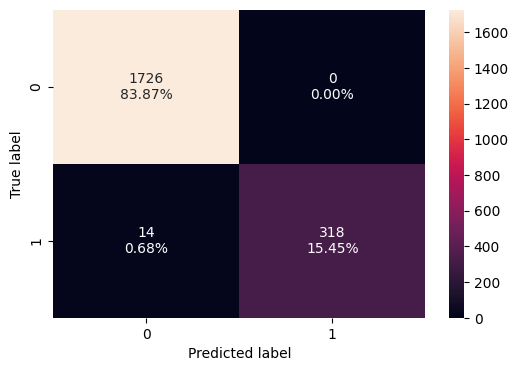

In [ ]:
confusion_matrix_sklearn(bagging, X_train, y_train)

**To check the accuracy of the training data of bagging classifier**

In [ ]:
bagging_model_train_perf = model_performance_classification_sklearn(bagging, X_train, y_train)
print("Training performance \n",bagging_model_train_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.993197  0.957831        1.0  0.978462


**plotting confusion matrix for test data of bagging classifier**

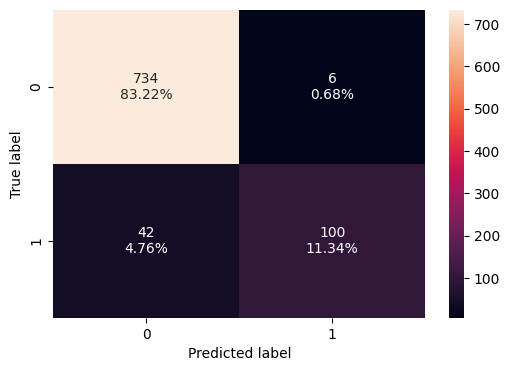

In [ ]:
confusion_matrix_sklearn(bagging, X_test, y_test)

**To check the accuracy of the test data of bagging classifier**

In [ ]:
bagging_model_test_perf=model_performance_classification_sklearn(bagging, X_test, y_test)
print("Testing performance \n",bagging_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.945578  0.704225   0.943396  0.806452


**Observation**

* Bagging classifier is overfitting on the training set and is performing poorly on the test set in terms of recall.

**Bagging Classifier with weighted decision tree**

* **Weighted Decision Tree:** A standard decision tree builds its splits to maximize information gain.

* A weighted decision tree introduces a modification during its training process.

**Why combine them and why for this dataset?**

* dataset likely has a class imbalance (fewer 'Yes' attrition cases than 'No').

In [ ]:
bagging_wt = BaggingClassifier(DecisionTreeClassifier(criterion='gini',class_weight={0:0.17,1:0.83},random_state=1),random_state=1)
bagging_wt.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(class_weight={0: 0.17,
                                                                 1: 0.83},
                                                   random_state=1),
                  random_state=1)

**Plotting confusion matrixs for training data**

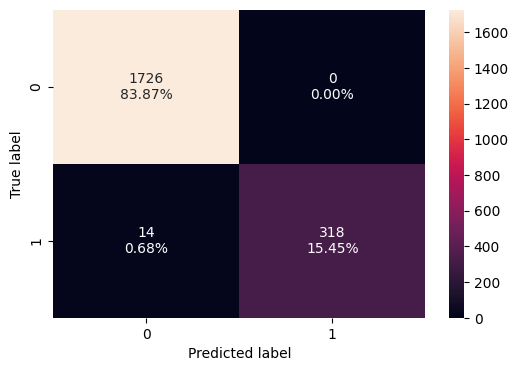

In [ ]:
confusion_matrix_sklearn(bagging_wt,X_train,y_train)

**To check the accuracy of training data**

In [ ]:
bagging_wt_model_train_perf=model_performance_classification_sklearn(bagging_wt,X_train,y_train)
print("Training performance \n",bagging_wt_model_train_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.993197  0.957831        1.0  0.978462


**Plotting confusion matrix for test data**

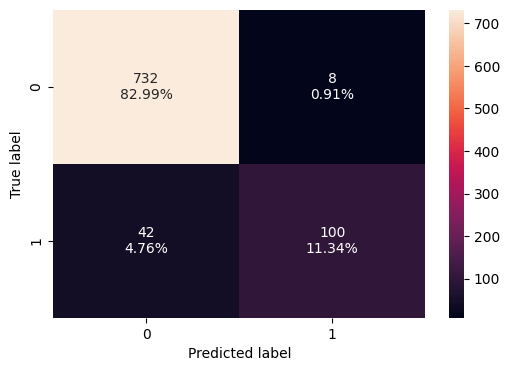

In [ ]:
confusion_matrix_sklearn(bagging_wt,X_test,y_test)

**To check the accuracy of test data**

In [ ]:
bagging_wt_model_test_perf=model_performance_classification_sklearn(bagging_wt, X_test, y_test)
print("Testing performance \n",bagging_wt_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision   F1
0  0.943311  0.704225   0.925926  0.8


**Observations**

* Bagging classifier with a weighted decision tree is giving very good accuracy and prediction but is not able to perform well on test data in terms of recall.

# **Random Forest**

* It is a one of the powerful ensemble methid similar to bagging but with and added layer of randomness.

* it is built on the concept of decision tree.

* Like Bagging, Random Forest constructs multiple decision trees during training

In [ ]:
rf = RandomForestClassifier(random_state = 1)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

**plotting confusion matrix on train data for RF**

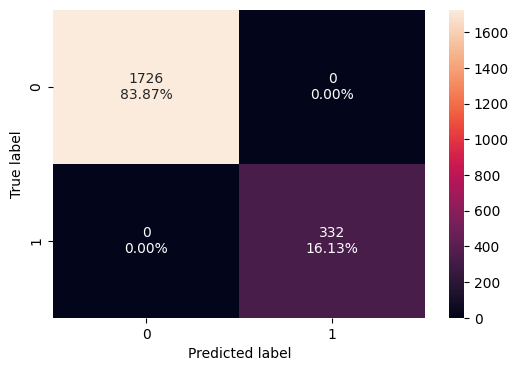

In [ ]:
confusion_matrix_sklearn(rf,X_train,y_train)

**To check the accuracy of the train data**

In [ ]:
rf_model_train_perf=model_performance_classification_sklearn(rf,X_train,y_train)
print("Training performance \n",rf_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


**plotting confusion matrix for test data**

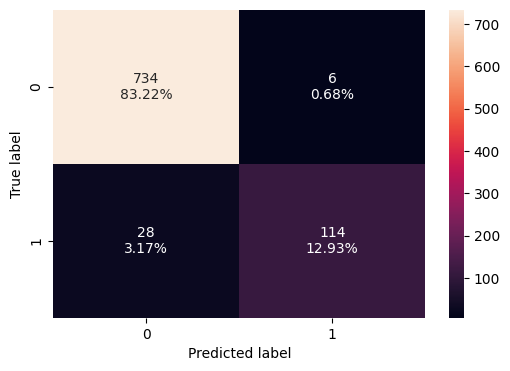

In [ ]:
confusion_matrix_sklearn(rf, X_test, y_test)

**To check the accuracy of the test data**

In [ ]:
rf_model_test_perf = model_performance_classification_sklearn(rf, X_test, y_test)
print("Testing performance \n",rf_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.961451  0.802817       0.95  0.870229


**Observation:**

* Random Forest has performed well in terms of accuracy and precision, but it is not able to perform well on the test data in terms of recall.

# **Comparing all the models**

In [ ]:
models_train_comp_df = pd.concat(
    [dtree_model_train_perf.T,
    bagging_model_train_perf.T,
    bagging_wt_model_train_perf.T,
    rf_model_train_perf.T,
    log_reg_train_perf.T,
    knn_train_perf.T],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree",
    "Bagging Classifier",
    "Weighted Bagging Classifier",
    "Random Forest Classifier",
    "Logistic Regression",
    "K-Nearest Neighbors"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree,Bagging Classifier,Weighted Bagging Classifier,Random Forest Classifier,Logistic Regression,K-Nearest Neighbors
Accuracy,1.0,0.993197,0.993197,1.0,0.781827,0.882896
Recall,1.0,0.957831,0.957831,1.0,0.771084,0.352410
Precision,1.0,1.000000,1.000000,1.0,0.406995,0.818182
F1,1.0,0.978462,0.978462,1.0,0.532778,0.492632


**Observations:**

* the tree-based models (Decision Tree, Random Forest, Bagging, Weighted Bagging) show clear signs of overfitting on the training data, achieving near-perfect scores.

* Logistic Regression and KNN show more balanced or distinct performance profiles, which will need to be further evaluated against their test performance to determine their true effectiveness and generalization capabilities.

In [ ]:
models_test_comp_df = pd.concat(
    [dtree_model_test_perf.T,
    bagging_model_test_perf.T,
    bagging_wt_model_test_perf.T,
    rf_model_test_perf.T,
    log_reg_test_perf.T,
    knn_test_perf.T],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree",
    "Bagging Classifier",
    "Weighted Bagging Classifier",
    "Random Forest Classifier",
    "Logistic Regression",
    "K-Nearest Neighbors"
]
print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Bagging Classifier,Weighted Bagging Classifier,Random Forest Classifier,Logistic Regression,K-Nearest Neighbors
Accuracy,0.936508,0.945578,0.943311,0.961451,0.783447,0.851474
Recall,0.830986,0.704225,0.704225,0.802817,0.788732,0.246479
Precision,0.786667,0.943396,0.925926,0.950000,0.410256,0.593220
F1,0.808219,0.806452,0.800000,0.870229,0.539759,0.348259


**Observations:**

* Based on the test performance, the Random Forest Classifier appears to be the most robust model for predicting employee attrition, offering the best balance of accuracy, precision, and recall.

* The high Recall of the Logistic Regression model, despite its low precision, might be useful in scenarios where identifying every possible attrition case is paramount, even with many false positives.

*  KNN, in its current form, is not performing well enough for this task.

# **Feature importance of Random Forest**

In [ ]:
print (pd.DataFrame(rf.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                        Imp
MonthlyIncome                      0.080810
OverTime_Yes                       0.059174
Age                                0.055292
DailyRate                          0.053302
TotalWorkingYears                  0.052114
HourlyRate                         0.050174
MonthlyRate                        0.048463
DistanceFromHome                   0.047056
YearsAtCompany                     0.039540
PercentSalaryHike                  0.031674
YearsWithCurrManager               0.031058
YearsInCurrentRole                 0.029408
NumCompaniesWorked                 0.029030
TrainingTimesLastYear              0.028230
EnvironmentSatisfaction            0.026136
StockOptionLevel                   0.025781
JobInvolvement                     0.025729
JobSatisfaction                    0.025468
WorkLifeBalance                    0.025087
JobLevel                           0.023950
YearsSinceLastPromotion            0.023892
Education                       

In [ ]:
feature_names = X_train.columns

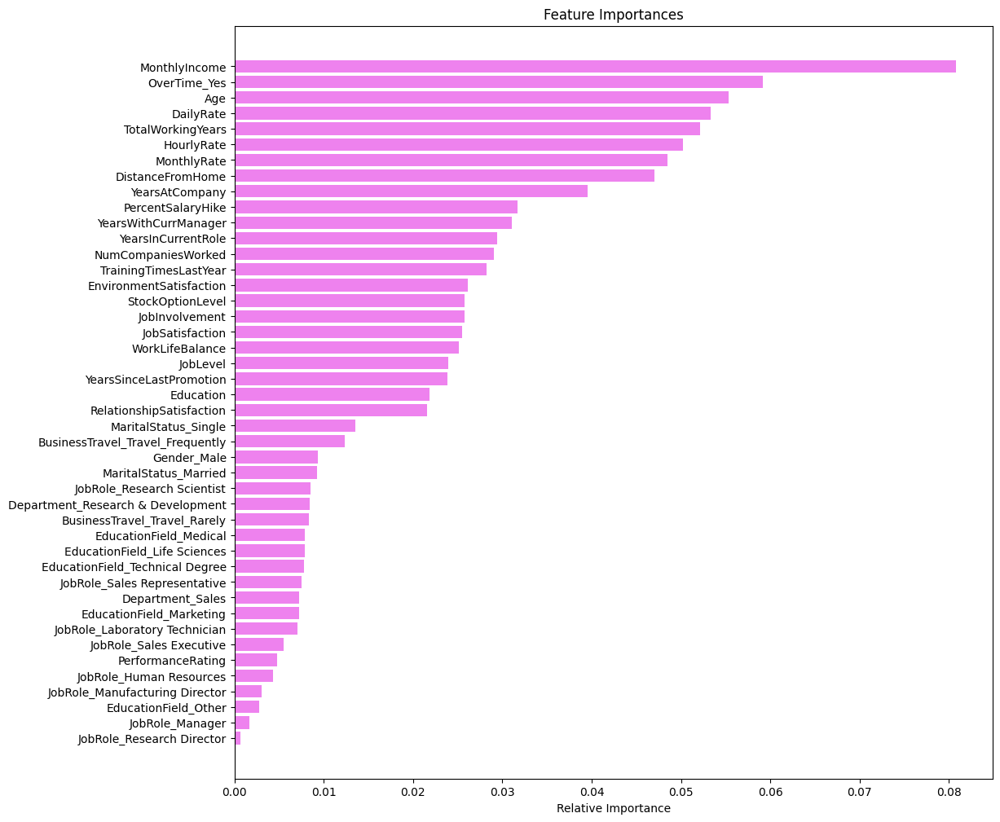

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

**Observations:**

* Monthly income is the most important feature for prediction followed by Overtime, Daily Rate and Age.